In [2]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix
from datacleaning import customer_handle_missing_values

from utils import (
    scaling,
    plot_dendrogram,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette
)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,years_tenure,...,total_spend,perc_spend_vegetables,perc_spend_meat_fish,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_alcohol_drinks,perc_spend_hygiene,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,6,...,18590.0,0.020065,0.012964,0.020656,0.258687,0.631038,0.354000,0.029693,38.794428,-9.215739
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,13,...,20233.0,0.099442,0.002867,0.032867,0.064054,0.676815,0.151274,0.092918,38.751711,-9.179611
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,21,...,15549.0,0.035694,0.098913,0.014277,0.006496,0.797929,0.538813,0.032607,38.780678,-9.160656
7,John Kelling,male,44,Unknown,0,0,0,0,2021,5,...,14952.0,0.005618,0.137440,0.012306,0.184658,0.501137,0.599471,0.032437,38.739548,-9.148679
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,5,...,25797.0,0.014730,0.080746,0.017095,0.469008,0.356127,0.548092,0.011513,38.733071,-9.188188


In [4]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'has_children',
       'year_first_transaction', 'years_tenure', 'distinct_stores_visited',
       'number_complaints', 'typical_hour', 'time_of_day',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_alcohol_drinks', 'perc_spend_hygiene', 'latitude', 'longitude'

In [5]:
features = [
    'customer_age',
    'number_complaints',
    'total_children',
    'percentage_of_products_bought_promotion',
    'perc_spend_vegetables',
    'perc_spend_meat_fish',
    'perc_spend_tech_entertainment',
    'years_tenure',
    'distinct_stores_visited'
]

X = dataset[features].copy()
X.columns

Index(['customer_age', 'number_complaints', 'total_children',
       'percentage_of_products_bought_promotion', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_tech_entertainment', 'years_tenure',
       'distinct_stores_visited'],
      dtype='object')

In [6]:
# Depois faz o scaling normalmente
X_scaled = scaling(X)

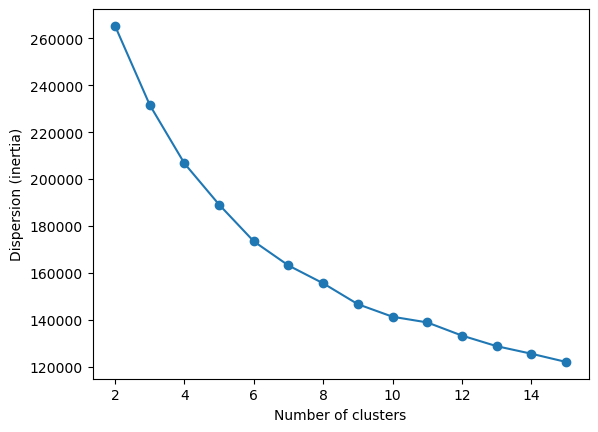

In [7]:
K_range = 15

inertias = []

for k in range(2, K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(experimental_kmeans.inertia_)

plt.plot(range(2, K_range+1), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

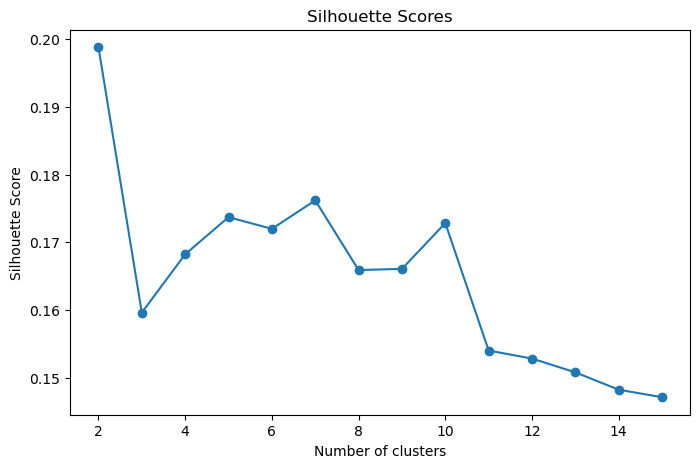

In [8]:
scores = []

for k in range(2,K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = experimental_kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

k=8 | silhouette=0.1659
k=9 | silhouette=0.1661
k=10 | silhouette=0.1728


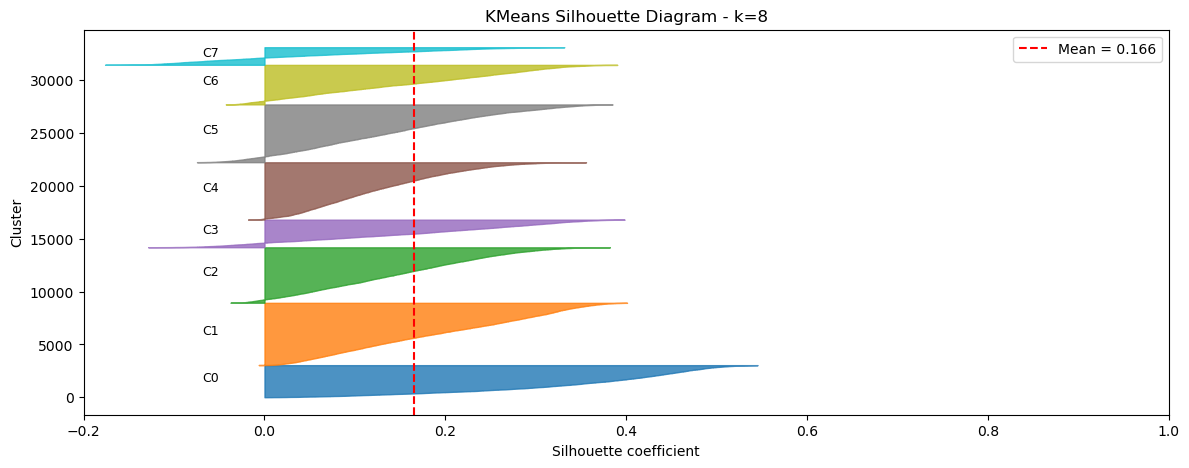

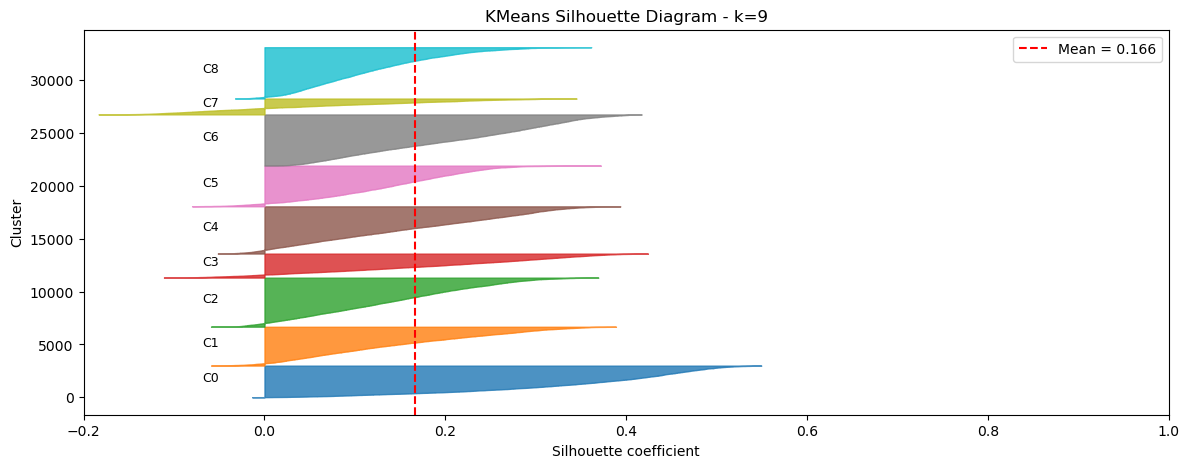

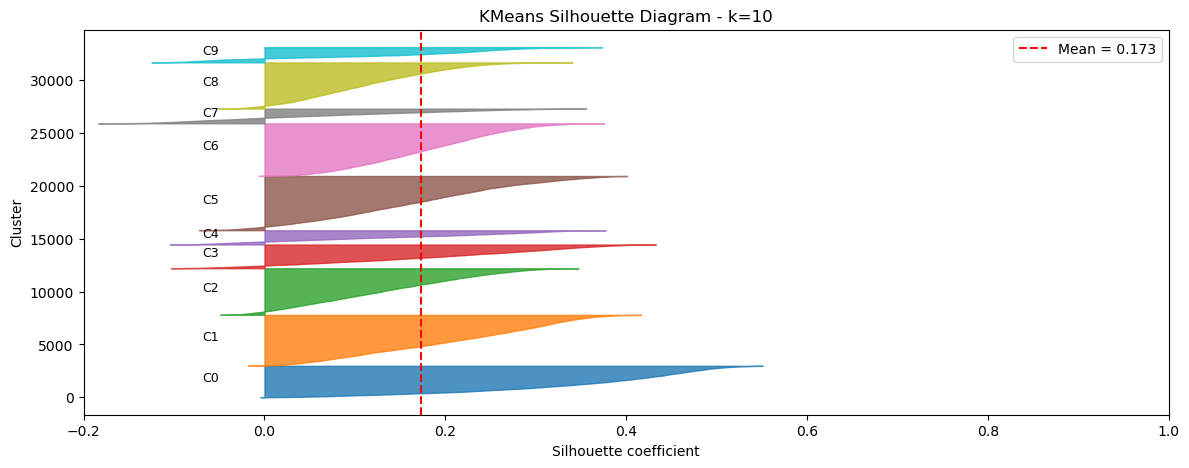

In [9]:
for k in [8, 9, 10]:
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = experimental_kmeans.fit_predict(X_scaled)

    score = plot_silhouette(
        X_scaled,
        labels,
        title=f"KMeans Silhouette Diagram - k={k}"
    )

    print(f"k={k} | silhouette={score:.4f}")

In [14]:
kmeans = KMeans(n_clusters= 9, random_state=42, n_init='auto').fit(X_scaled)
dataset['cluster_kmeans'] = kmeans.predict(X_scaled)


In [15]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
8    4845
6    4826
2    4632
4    4458
5    3840
1    3665
0    2985
3    2261
7    1493
Name: count, dtype: int64

In [16]:
X['cluster_kmeans'] = dataset['cluster_kmeans']

In [17]:
X.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6,7,8
customer_age,57.278392,33.708322,59.164940,58.259620,58.270525,41.044792,62.309159,59.268587,64.330031
number_complaints,1.068342,0.470123,0.817142,0.904025,0.678780,2.424479,0.413800,0.971869,0.867492
total_children,0.561474,1.362347,1.361183,7.019903,1.941454,2.553385,1.666390,1.587408,1.802890
percentage_of_products_bought_promotion,0.260267,0.305207,0.756723,0.204515,0.120430,0.446423,0.177894,0.427588,0.210558
perc_spend_vegetables,0.007803,0.029236,0.024600,0.023200,0.143049,0.019430,0.028028,0.056337,0.031504
perc_spend_meat_fish,0.075623,0.052745,0.068810,0.078921,0.014029,0.068082,0.062385,0.199099,0.043576
perc_spend_tech_entertainment,0.498429,0.086118,0.072856,0.153205,0.129264,0.083367,0.071105,0.164481,0.081696
years_tenure,8.895812,6.056207,11.850173,13.615657,10.868327,9.136979,14.758806,11.444742,11.313725
distinct_stores_visited,1.457286,3.032196,4.428972,3.245909,3.163751,2.340104,1.899710,3.575352,4.873271


In [18]:
numeric_cols = dataset.select_dtypes(include='number')

numeric_cols = numeric_cols.drop(
    ['kids_home', 
    'teens_home', 
    'has_children', 
    'year_first_transaction', 
    'lifetime_spend_meat', 
    'lifetime_spend_fish',
    'lifetime_spend_nonalcohol_drinks',
    'latitude',
    'longitude'], axis = 1)

numeric_cols.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6,7,8
customer_age,57.278392,33.708322,59.164940,58.259620,58.270525,41.044792,62.309159,59.268587,64.330031
total_children,0.561474,1.362347,1.361183,7.019903,1.941454,2.553385,1.666390,1.587408,1.802890
years_tenure,8.895812,6.056207,11.850173,13.615657,10.868327,9.136979,14.758806,11.444742,11.313725
distinct_stores_visited,1.457286,3.032196,4.428972,3.245909,3.163751,2.340104,1.899710,3.575352,4.873271
number_complaints,1.068342,0.470123,0.817142,0.904025,0.678780,2.424479,0.413800,0.971869,0.867492
typical_hour,17.393635,13.392633,14.006261,10.166298,12.927770,10.858594,9.775176,13.176825,13.019608
lifetime_total_distinct_products,110.164489,138.110505,142.673575,297.285714,95.967026,96.019792,169.826772,147.176825,187.046233
percentage_of_products_bought_promotion,0.260267,0.305207,0.756723,0.204515,0.120430,0.446423,0.177894,0.427588,0.210558
lifetime_spend_groceries,8086.474372,18028.663847,18426.044257,24786.090668,9001.650067,14239.351823,20590.653543,3688.811788,21916.222291
lifetime_spend_vegetables,176.049581,605.136153,414.006693,805.238390,1916.152535,342.528385,648.594695,448.528466,698.341589


Cluster 0: Tech-oriented customers
    - 

Cluster 1: Young customers

Cluster 2: Promotion-sensitive customers


In [ ]:
dataset['']

In [220]:
experimental_hierarchical = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(X_scaled)

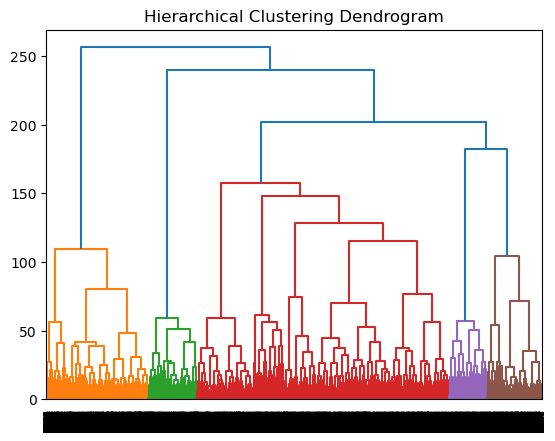

In [221]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(experimental_hierarchical, truncate_mode="level", p=50)
plt.show()


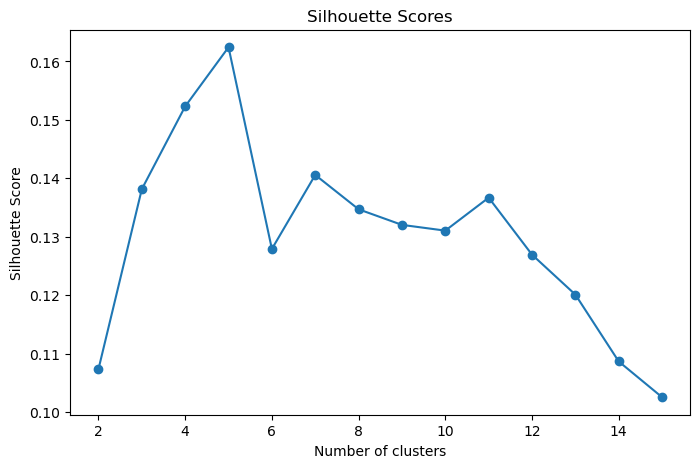

In [222]:
scores = []

for k in range(2,K_range+1):
    experimental_hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = experimental_hierarchical.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [227]:
dataset['cluster_agglomerative'] = AgglomerativeClustering(linkage='ward', n_clusters=9).fit_predict(X_scaled)

In [228]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'has_children',
       'year_first_transaction', 'years_tenure', 'distinct_stores_visited',
       'number_complaints', 'typical_hour', 'time_of_day',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_alcohol_drinks', 'perc_spend_hygiene', 'latitude', 'longitude'

In [229]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33005 entries, 3 to 40000
Data columns (total 40 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33005 non-null  object 
 1   customer_gender                          33005 non-null  object 
 2   customer_age                             33005 non-null  int64  
 3   education_level                          33005 non-null  object 
 4   kids_home                                33005 non-null  int64  
 5   teens_home                               33005 non-null  int64  
 6   total_children                           33005 non-null  int64  
 7   has_children                             33005 non-null  int64  
 8   year_first_transaction                   33005 non-null  int64  
 9   years_tenure                             33005 non-null  int64  
 10  distinct_stores_visited                  33005 non-

In [230]:
pd.DataFrame(
    confusion_matrix(
        dataset['cluster_kmeans'],
        dataset['cluster_agglomerative']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 9)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 9)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster,Hierarchical 8 Cluster
K-Means 0 Cluster,0,4,54,3,1,7,2904,2,10
K-Means 1 Cluster,695,34,153,534,116,331,78,1569,155
K-Means 2 Cluster,0,43,326,234,3,7,3,550,3466
K-Means 3 Cluster,5,83,45,61,2028,32,1,0,6
K-Means 4 Cluster,4423,6,10,3,0,11,0,0,5
K-Means 5 Cluster,37,3396,16,195,55,19,53,9,60
K-Means 6 Cluster,427,14,146,463,170,3232,102,1,271
K-Means 7 Cluster,1,47,1226,34,9,8,90,10,68
K-Means 8 Cluster,1219,13,69,2366,159,101,4,22,892


In [19]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled)


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


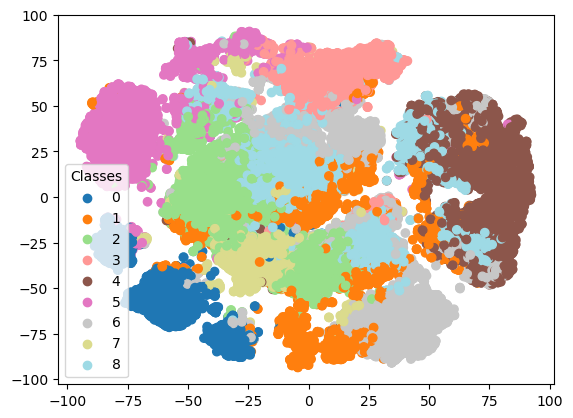

In [20]:
visualize_dimensionality_reduction(tsne_transformation, dataset['cluster_kmeans'])    


In [21]:
umap = UMAP(n_neighbors=50, random_state=0)



umap_transformation = umap.fit_transform(X_scaled)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


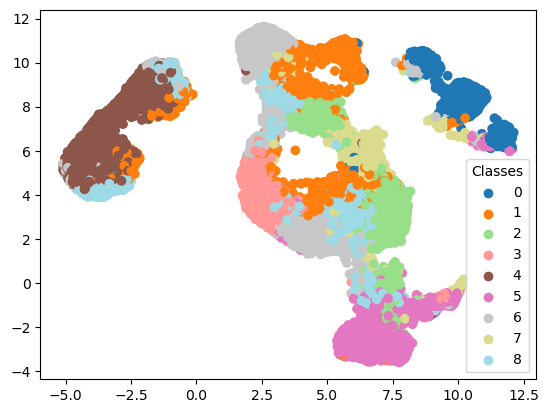

In [22]:
visualize_dimensionality_reduction(umap_transformation, dataset['cluster_kmeans'])